In [ ]:
pip install fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567858 sha256=08d75e8490d6ff679b23a1d259e2389f716d23f8942369b5cdb260268eb7472d
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = pd.read_csv('/content/drive/MyDrive/국민대_무역_공모전/데이터/train.csv')
submission = pd.read_csv('/content/drive/MyDrive/국민대_무역_공모전/데이터/submission.csv')

In [5]:
# ================================
# 1) 월별 집계
# ================================
monthly = (
    train.groupby(['item_id', 'year', 'month'])
         .agg({
             'value': 'sum',
             'weight': 'sum',
             'quantity': 'sum',
             'hs4': 'first'
         })
         .reset_index()
)

# ================================
# 2) year_month 생성
# ================================
monthly['year_month'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' + monthly['month'].astype(str),
    format='%Y-%m'
)

# ================================
# 3) Value 피벗 (행: year_month, 열: item_id)
# ================================
pivot_value = (
    monthly.pivot_table(
        index='year_month',
        columns='item_id',
        values='value',
        fill_value=0
    )
    .sort_index()
)

# ================================
# 4) Weight 피벗 (행: year_month, 열: item_id)
# ================================
pivot_weight = (
    monthly.pivot_table(
        index='year_month',
        columns='item_id',
        values='weight',
        fill_value=0
    )
    .sort_index()
)

# ================================
# 5) Transpose (행 = item_id 로 변경)
# ================================
pivot = pivot_value.T           # (n_items × n_months)
pivot_weight_T = pivot_weight.T # 동일 구조

# ================================
# 6) 기본 출력
# ================================
print("✓ Value pivot:", pivot_value.shape)
print("✓ Weight pivot:", pivot_weight.shape)
pivot.head(5)


✓ Value pivot: (43, 100)
✓ Weight pivot: (43, 100)


year_month,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,...,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01
item_id,,,,,,,,,,,,,,,,,,,,,
AANGBULD,14276.0,52347.0,53549.0,0.0,26997.0,84489.0,0.0,0.0,0.0,0.0,...,428725.0,144248.0,26507.0,25691.0,25805.0,0.0,38441.0,0.0,441275.0,533478.0
AHMDUILJ,242705.0,120847.0,197317.0,126142.0,71730.0,149138.0,186617.0,169995.0,140547.0,89292.0,...,123085.0,143451.0,78649.0,125098.0,80404.0,157401.0,115509.0,127473.0,89479.0,101317.0
ANWUJOKX,0.0,0.0,0.0,63580.0,81670.0,26424.0,8470.0,0.0,0.0,80475.0,...,0.0,0.0,0.0,27980.0,0.0,0.0,0.0,0.0,0.0,0.0
APQGTRMF,383999.0,512813.0,217064.0,470398.0,539873.0,582317.0,759980.0,216019.0,537693.0,205326.0,...,683581.0,2147.0,0.0,25013.0,77.0,20741.0,2403.0,3543.0,32430.0,40608.0
ATLDMDBO,143097177.0,103568323.0,118403737.0,121873741.0,115024617.0,65716075.0,146216818.0,97552978.0,72341427.0,87454167.0,...,60276050.0,30160198.0,42613728.0,64451013.0,38667429.0,29354408.0,42450439.0,37136720.0,32181798.0,57090235.0


In [6]:
from scipy.stats import pearsonr

def safe_corr_with_pvalue(x, y):
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0, 1.0
    corr, p_value = pearsonr(x, y)
    return float(corr), float(p_value) # 피어슨 상관계수, p-value

In [7]:
def calculate_score_advanced(corr, p_value, lag):
    """
    상관계수(70%) + p-value(20%) + lag(10%)
    """
    # 상관계수 (0~70점)
    corr_score = abs(corr) * 70

    # 통계적 유의성 (0~20점)
    if p_value < 0.001:
        sig_score = 20
    elif p_value < 0.01:
        sig_score = 15
    elif p_value < 0.05:
        sig_score = 10
    else:
        sig_score = 5

    # Lag (0~10점) - 짧을수록 좋음
    if lag <= 2:
        lag_score = 10
    elif lag <= 4:
        lag_score = 7
    elif lag <= 6:
        lag_score = 4
    else:
        lag_score = 1

    return corr_score + sig_score + lag_score

## DTW 값이 작을수록 패턴이 유사

DTW (Dynamic Time Warping)은 시계열 데이터 간의 유사성을 비교하기 위한 알고리즘이다. DTW는 시계열 데이터 간의 길이나 속도가 달라도, 이것을 고려하여 유사성을 측정할 수 있기 때문에 시계열 데이터 분석에 많이 활용된다.

왜 DTW를 쓰는가?
상관계수만으로는 놓치는 것:

- 속도 차이 (A는 천천히, B는 빠르게 변함)
- 타이밍 차이 (A가 먼저 변하고 B가 조금 늦게 따라감)
- 노이즈 (한두 달 튀는 값)

DTW는 이런 것까지 고려해서 "진짜 패턴 유사도"를 측정

In [8]:
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler

# DTW 함수
def dtw_distance(series_A, series_B):
    """
    Dynamic Time Warping 거리 계산
    """
    n, m = len(series_A), len(series_B)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(series_A[i-1] - series_B[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )

    return dtw_matrix[n, m]

def calculate_normalized_dtw(x, y, lag):
    """
    정규화 + DTW 거리 계산
    x: 선행 품목
    y: 후행 품목
    lag: 시차
    """
    if len(x) <= lag or len(y) <= lag:
        return float('inf')

    x_aligned = x[:-lag]
    y_aligned = y[lag:]

    if len(x_aligned) < 5:
        return float('inf')

    # 정규화
    scaler = StandardScaler()
    normalized_x = scaler.fit_transform(x_aligned.reshape(-1, 1)).flatten()
    normalized_y = scaler.fit_transform(y_aligned.reshape(-1, 1)).flatten()

    # DTW 거리
    distance = dtw_distance(normalized_x, normalized_y)

    # 길이로 정규화
    normalized_distance = distance / len(normalized_x)
    return normalized_distance

def find_comovement_pairs(
    pivot,
    max_lag=9,
    min_nonzero=12,
    corr_threshold=0.4,
    score_threshold=45,
    use_dtw=True,              # DTW 사용 여부
    dtw_threshold=2.0          # DTW 임계값
):
    items = pivot.index.to_list()
    months = pivot.columns.to_list()
    n_months = len(months)
    results = []

    for i, leader in tqdm(enumerate(items), total=len(items), desc="Finding pairs"):
        x = pivot.loc[leader].values.astype(float)
        if np.count_nonzero(x) < min_nonzero:
            continue

        candidates = []

        for follower in items:
            if follower == leader:
                continue

            y = pivot.loc[follower].values.astype(float)
            if np.count_nonzero(y) < min_nonzero:
                continue

            best_lag = None
            best_corr = 0.0
            best_p_value = 1.0
            best_dtw = float('inf')

            # lag 탐색
            for lag in range(1, max_lag + 1):
                if n_months <= lag:
                    continue

                corr, p_value = safe_corr_with_pvalue(x[:-lag], y[lag:])

                if abs(corr) > abs(best_corr):
                    best_corr = corr
                    best_lag = lag
                    best_p_value = p_value

            # 1단계: 상관계수 임계값 통과 시
            if best_lag is not None and abs(best_corr) >= corr_threshold:

                # 2단계: DTW 검증 (옵션)
                if use_dtw:
                    best_dtw = calculate_normalized_dtw(x, y, best_lag)

                    # DTW 임계값 통과 못하면 스킵
                    if best_dtw > dtw_threshold:
                        continue

                # 종합 점수 계산
                score = calculate_score_advanced(
                    best_corr, best_p_value, best_lag
                )

                # DTW 점수 반영 (옵션)
                if use_dtw and best_dtw != float('inf'):
                    # DTW가 낮을수록 좋으므로 역수 사용
                    dtw_bonus = 1 / (1 + best_dtw)
                    score = score * (1 + dtw_bonus)  # DTW 보너스 추가

                # 점수 임계값 통과 시 후보에 추가
                if score >= score_threshold:
                    candidates.append({
                        "following_item_id": follower,
                        "best_lag": best_lag,
                        "max_corr": best_corr,
                        "p_value": best_p_value,
                        "dtw_distance": best_dtw if use_dtw else None,
                        "comovement_score": score
                    })

        # 점수 순으로 정렬 (높은 순)
        candidates.sort(key=lambda x: -x['comovement_score'])

        for candidate in candidates:
            result_dict = {
                "leading_item_id": leader,
                "following_item_id": candidate["following_item_id"],
                "best_lag": candidate["best_lag"],
                "max_corr": candidate["max_corr"]
            }

            # DTW 사용 시 추가 정보 포함
            if use_dtw:
                result_dict["dtw_distance"] = candidate["dtw_distance"]
                result_dict["comovement_score"] = candidate["comovement_score"]

            results.append(result_dict)

    pairs = pd.DataFrame(results)
    return pairs

# 사용 예시

# # DTW 없이 (기존 방식)
# pairs_basic = find_comovement_pairs(
#     pivot,
#     max_lag=9,
#     min_nonzero=12,
#     corr_threshold=0.4,
#     score_threshold=35,
#     use_dtw=False
# )

# DTW 추가 (상관계수 + DTW 하이브리드)
pairs_with_dtw= find_comovement_pairs(
    pivot,
    max_lag=9,
    min_nonzero=12,
    corr_threshold=0.33,      # 1차 필터: 상관계수
    score_threshold=40,
    use_dtw=True,            # DTW 활성화
    dtw_threshold=1.0       # 2차 필터: DTW 거리
)

# print(f"Basic pairs: {len(pairs_basic)}")
print(f"Pairs with DTW: {len(pairs_with_dtw)}")
print("\n=== Top 10 pairs with DTW ===")
print(pairs_with_dtw.head(20))

Finding pairs: 100%|██████████| 100/100 [00:50<00:00,  1.98it/s]

Pairs with DTW: 3368

=== Top 10 pairs with DTW ===
   leading_item_id following_item_id  best_lag  max_corr  dtw_distance  \
0         AANGBULD          ZCELVYQU         7  0.677701      0.304327   
1         AANGBULD          ZKENOUDA         1  0.599969      0.513452   
2         AANGBULD          DEWLVASR         6  0.640221      0.490232   
3         AANGBULD          NAQIHUKZ         2  0.525490      0.471456   
4         AANGBULD          GKQIJYDH         6  0.582501      0.464203   
5         AANGBULD          FTSVTTSR         3  0.531400      0.519376   
6         AANGBULD          VUAFAIYJ         2  0.509968      0.671474   
7         AANGBULD          KJNSOAHR         9  0.575636      0.454634   
8         AANGBULD          ZXERAXWP         9  0.569322      0.514398   
9         AANGBULD          XIIEJNEE         7  0.526602      0.436966   
10        AANGBULD          LLHREMKS         5  0.499734      0.485700   
11        AANGBULD          ELQGMQWE         8  0.474939    

In [9]:
# ============================================================
#  ⬇⬇⬇⬇⬇⬇⬇⬇  여기에 넣어라: Pairs 생성 직후 위치  ⬇⬇⬇⬇⬇⬇⬇⬇
# ============================================================

# 1) pivot 기반 전체 item graph 생성
import networkx as nx
import numpy as np
from community import community_louvain  # Louvain

# --- 그래프 생성 ---
def build_item_graph(pivot_value, corr_thr=0.3, lag_thr=0.2, max_lag=3):

    items = pivot_value.columns.tolist()
    G = nx.DiGraph()

    # Pearson corr
    corr_matrix = pivot_value.corr()

    # lagged corr
    def lag_corr(a, b):
        a = a - a.mean()
        b = b - b.mean()
        best = 0
        for lag in range(1, max_lag + 1):
            if len(a) <= lag: break
            c = np.corrcoef(a[:-lag], b[lag:])[0, 1]
            best = max(best, abs(c))
        return best

    for i in items:
        for j in items:
            if i == j: continue
            w1 = corr_matrix.loc[i, j]
            if abs(w1) >= corr_thr:
                G.add_edge(i, j, weight=float(w1))

            w2 = lag_corr(pivot_value[i].values, pivot_value[j].values)
            if w2 >= lag_thr:
                G.add_edge(i, j, weight=float(w2))

    return G


# pivot_value는 year_month × item_id 형태이므로 다시 transpose
pivot_value_for_graph = pivot_value.copy()

G = build_item_graph(pivot_value_for_graph)

print("그래프 노드수:", G.number_of_nodes())
print("그래프 엣지수:", G.number_of_edges())


# --- Louvain Community ---
partition = community_louvain.best_partition(G.to_undirected(), weight='weight')
louvain_df = pd.DataFrame({'item_id': list(partition.keys()),
                           'community': list(partition.values())})


# --- Greedy Modularity ---
greedy_com = nx.algorithms.community.greedy_modularity_communities(G.to_undirected())
greedy_assign = {}
for cid, group in enumerate(greedy_com):
    for node in group:
        greedy_assign[node] = cid

greedy_df = pd.DataFrame({'item_id': list(greedy_assign.keys()),
                          'community': list(greedy_assign.values())})


# --- Centrality ---
in_deg  = dict(G.in_degree(weight='weight'))
out_deg = dict(G.out_degree(weight='weight'))
close   = nx.closeness_centrality(G)
btwn    = nx.betweenness_centrality(G, weight='weight')

centrality_df = pd.DataFrame({
    'item_id': list(G.nodes()),
    'in_degree': [in_deg.get(i, 0) for i in G.nodes()],
    'out_degree': [out_deg.get(i, 0) for i in G.nodes()],
    'closeness': [close.get(i, 0) for i in G.nodes()],
    'betweenness': [btwn.get(i, 0) for i in G.nodes()]
})


# -------------------------
# 2) pair_df에 feature merge
# -------------------------

# dict 형태로 변환
louvain_map = dict(zip(louvain_df['item_id'], louvain_df['community']))
greedy_map  = dict(zip(greedy_df['item_id'], greedy_df['community']))
cent_map    = centrality_df.set_index('item_id').to_dict(orient='index')


def add_graph_features(row):

    A = row.leading_item_id
    B = row.following_item_id

    # Louvain
    cA = louvain_map.get(A, -1)
    cB = louvain_map.get(B, -1)

    # Greedy
    gA = greedy_map.get(A, -1)
    gB = greedy_map.get(B, -1)

    # centrality
    CA = cent_map.get(A, {'in_degree':0,'out_degree':0,'closeness':0,'betweenness':0})
    CB = cent_map.get(B, {'in_degree':0,'out_degree':0,'closeness':0,'betweenness':0})

    return pd.Series({
        'lead_comm': cA,
        'foll_comm': cB,
        'same_comm': int(cA == cB),

        'lead_greedy': gA,
        'foll_greedy': gB,
        'same_greedy': int(gA == gB),

        'lead_in_deg': CA['in_degree'],
        'foll_in_deg': CB['in_degree'],
        'deg_gap': CA['in_degree'] - CB['in_degree'],
        'deg_ratio': CA['in_degree'] / (CB['in_degree'] + 1e-6),

        'lead_btwn': CA['betweenness'],
        'foll_btwn': CB['betweenness'],
        'btwn_gap': CA['betweenness'] - CB['betweenness'],
        'btwn_ratio': CA['betweenness'] / (CB['betweenness'] + 1e-6),
    })


graph_feats = pairs_with_dtw.apply(add_graph_features, axis=1)
pairs_with_dtw = pd.concat([pairs_with_dtw, graph_feats], axis=1)

print("그래프 기반 feature 추가 완료!")
print(pairs_with_dtw.head())

그래프 노드수: 100
그래프 엣지수: 5375
그래프 기반 feature 추가 완료!
  leading_item_id following_item_id  best_lag  max_corr  dtw_distance  \
0        AANGBULD          ZCELVYQU         7  0.677701      0.304327   
1        AANGBULD          ZKENOUDA         1  0.599969      0.513452   
2        AANGBULD          DEWLVASR         6  0.640221      0.490232   
3        AANGBULD          NAQIHUKZ         2  0.525490      0.471456   
4        AANGBULD          GKQIJYDH         6  0.582501      0.464203   

   comovement_score  lead_comm  foll_comm  same_comm  lead_greedy  \
0        120.909908        0.0        3.0        0.0          1.0   
1        119.569775        0.0        0.0        1.0          1.0   
2        114.993153        0.0        0.0        1.0          1.0   
3        112.170840        0.0        3.0        0.0          1.0   
4        109.014231        0.0        3.0        0.0          1.0   

   foll_greedy  same_greedy  lead_in_deg  foll_in_deg    deg_gap  deg_ratio  \
0          1.0    

# 기존 추출된 pair들, 네트워크 극단값 기반으로 저품질 제거하고 모델링에 넣기 (옵션2 - 데이터 품질 향상)

In [10]:
### 안쓸땐 주석처리

# === (A) 그래프 기반 재가중치 + pair 필터링 (Stage1 품질 개선) ===
import numpy as np

# 그래프 피처까지 merge가 끝난 최종 pair 테이블
# columns 예시: leading_item_id, following_item_id, best_lag, max_corr,
#               dtw_distance, comovement_score,
#               lead_comm, foll_comm, same_comm,
#               lead_greedy, foll_greedy, same_greedy,
#               lead_in_deg, foll_in_deg, deg_gap, deg_ratio,
#               lead_btwn, foll_btwn, btwn_gap, btwn_ratio
pairs_for_model = pairs_with_dtw.copy()

# 1) deg_ratio, btwn_ratio 이상치/극단값 클리핑
deg_ratio_clipped = pairs_for_model['deg_ratio'].clip(0.3, 3.0)
btwn_ratio_raw = pairs_for_model['btwn_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)
btwn_ratio_clipped = btwn_ratio_raw.clip(0.3, 3.0)

# 2) 그래프 기반 가중 score 정의
#    - 기본: comovement_score
#    - same_comm == 1 인 쌍에 약간 보너스
#    - deg_ratio, btwn_ratio는 너무 세게 쓰지 않고 약한 지수로 반영
pairs_for_model['graph_score'] = (
    pairs_for_model['comovement_score']
    * (1.05 + 0.05 * pairs_for_model['same_comm'])     # same_comm 1이면 대략 10% 보너스
    * (deg_ratio_clipped / 1.5) ** 0.3                 # degree 비례 약하게 반영
    * (btwn_ratio_clipped) ** 0.2                      # betweenness 비례 아주 약하게 반영
)

# 3) leader별 상위 TOP_K 개 pair만 사용 (노이즈 쌍 컷)
TOP_K = 35  # 필요하면 바꿔보면서 실험

pairs_for_model = (
    pairs_for_model
    .sort_values(['leading_item_id', 'graph_score'], ascending=[True, False])
    .groupby('leading_item_id')
    .head(TOP_K)
    .reset_index(drop=True)
)

print("그래프 노드수는 그대로, 재가중치 후 사용될 pair 수:", len(pairs_for_model))
pairs_for_model.head()

그래프 노드수는 그대로, 재가중치 후 사용될 pair 수: 2888


,leading_item_id,following_item_id,best_lag,max_corr,dtw_distance,comovement_score,lead_comm,foll_comm,same_comm,lead_greedy,...,same_greedy,lead_in_deg,foll_in_deg,deg_gap,deg_ratio,lead_btwn,foll_btwn,btwn_gap,btwn_ratio,graph_score
0,AANGBULD,NAQIHUKZ,2,0.525490,0.471456,112.170840,0.0,3.0,0.0,1.0,...,1.0,20.448407,8.145517,12.302890,2.510388,0.003504,0.000000,0.003504,3504.432076,171.233359
1,AANGBULD,GKQIJYDH,6,0.582501,0.464203,109.014231,0.0,3.0,0.0,1.0,...,1.0,20.448407,11.049129,9.399278,1.850680,0.003504,0.000000,0.003504,3504.432076,151.868879
2,AANGBULD,FTSVTTSR,3,0.531400,0.519376,106.450898,0.0,3.0,0.0,1.0,...,1.0,20.448407,11.656946,8.791462,1.754182,0.003504,0.000722,0.002783,4.850420,145.934477
3,AANGBULD,ZKENOUDA,1,0.599969,0.513452,119.569775,0.0,0.0,1.0,1.0,...,0.0,20.448407,25.388316,-4.939909,0.805426,0.003504,0.000825,0.002680,4.244852,135.962344
4,AANGBULD,ZCELVYQU,7,0.677701,0.304327,120.909908,0.0,3.0,0.0,1.0,...,1.0,20.448407,15.473195,4.975213,1.321537,0.003504,0.002886,0.000618,1.213865,127.052069


In [11]:
pairs_for_model

,leading_item_id,following_item_id,best_lag,max_corr,dtw_distance,comovement_score,lead_comm,foll_comm,same_comm,lead_greedy,...,same_greedy,lead_in_deg,foll_in_deg,deg_gap,deg_ratio,lead_btwn,foll_btwn,btwn_gap,btwn_ratio,graph_score
0,AANGBULD,NAQIHUKZ,2,0.525490,0.471456,112.170840,0.0,3.0,0.0,1.0,...,1.0,20.448407,8.145517,12.302890,2.510388,0.003504,0.000000,0.003504,3504.432076,171.233359
1,AANGBULD,GKQIJYDH,6,0.582501,0.464203,109.014231,0.0,3.0,0.0,1.0,...,1.0,20.448407,11.049129,9.399278,1.850680,0.003504,0.000000,0.003504,3504.432076,151.868879
2,AANGBULD,FTSVTTSR,3,0.531400,0.519376,106.450898,0.0,3.0,0.0,1.0,...,1.0,20.448407,11.656946,8.791462,1.754182,0.003504,0.000722,0.002783,4.850420,145.934477
3,AANGBULD,ZKENOUDA,1,0.599969,0.513452,119.569775,0.0,0.0,1.0,1.0,...,0.0,20.448407,25.388316,-4.939909,0.805426,0.003504,0.000825,0.002680,4.244852,135.962344
4,AANGBULD,ZCELVYQU,7,0.677701,0.304327,120.909908,0.0,3.0,0.0,1.0,...,1.0,20.448407,15.473195,4.975213,1.321537,0.003504,0.002886,0.000618,1.213865,127.052069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2883,ZXERAXWP,YSYHGLQK,1,0.374210,0.571980,75.581012,0.0,3.0,0.0,0.0,...,0.0,16.549164,14.173036,2.376128,1.167651,0.304679,0.890229,-0.585549,0.342248,59.406884
2884,ZXERAXWP,STZDBITS,7,0.361019,0.624989,58.592246,0.0,3.0,0.0,0.0,...,0.0,16.549164,11.655973,4.893191,1.419801,0.304679,0.593177,-0.288497,0.513639,52.966587
2885,ZXERAXWP,KJNSOAHR,7,0.370593,0.673319,59.018251,0.0,0.0,1.0,0.0,...,1.0,16.549164,22.532921,-5.983758,0.734444,0.304679,0.350752,-0.046073,0.868643,50.945690
2886,ZXERAXWP,XUOIQPFL,1,-0.353922,0.863469,68.802086,0.0,2.0,0.0,0.0,...,1.0,16.549164,23.796487,-7.247324,0.695446,0.304679,0.810864,-0.506184,0.375746,47.165173


In [12]:
print(len(pairs_with_dtw)), print(len(pairs_for_model))

3368
2888


(None, None)



---



Finding pairs: 100%|██████████| 100/100 [00:39<00:00,  2.50it/s]


=== DTW Distance 분포 ===
count    1979.000000
mean        0.624854
std         0.163845
min         0.170224
25%         0.521891
50%         0.595291
75%         0.697127
max         1.387961
Name: dtw_distance, dtype: float64

25th percentile: 0.5218913155310957
50th percentile (median): 0.5952912986612865
75th percentile: 0.6971273554381627


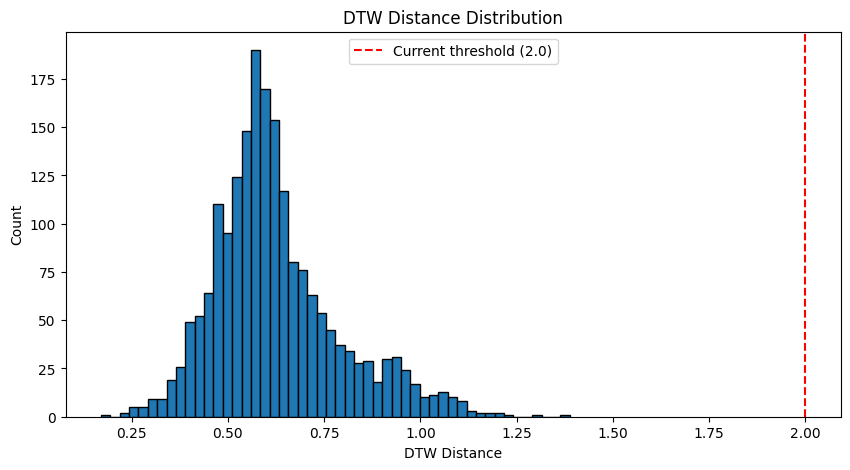

In [13]:
# 1. 먼저 DTW 분포 확인
pairs_with_dtw_info = find_comovement_pairs(
    pivot,
    max_lag=9,
    min_nonzero=12,
    corr_threshold=0.4,
    score_threshold=35,
    use_dtw=True,
    dtw_threshold=999  # 일단 전부 통과시키고
)

# DTW 거리 분포 확인
print("=== DTW Distance 분포 ===")
print(pairs_with_dtw_info['dtw_distance'].describe())
print(f"\n25th percentile: {pairs_with_dtw_info['dtw_distance'].quantile(0.25)}")
print(f"50th percentile (median): {pairs_with_dtw_info['dtw_distance'].quantile(0.50)}")
print(f"75th percentile: {pairs_with_dtw_info['dtw_distance'].quantile(0.75)}")

# 히스토그램으로 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(pairs_with_dtw_info['dtw_distance'], bins=50, edgecolor='black')
plt.xlabel('DTW Distance')
plt.ylabel('Count')
plt.title('DTW Distance Distribution')
plt.axvline(x=2.0, color='r', linestyle='--', label='Current threshold (2.0)')
plt.legend()
plt.show()

상관계수(corr_threshold=0.3)를 통과한 쌍들의 dtw분포, 즉 패턴 유사도를 보여줌



---



In [14]:
import os
import datetime

# result 폴더 생성 (이미 있으면 무시)
os.makedirs('./result', exist_ok=True)
date_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# 파일 저장
file_name = f'./result/sy_{date_str}.csv'
submission.to_csv(file_name, index=False)

## ✅ 조건부 Weight 피처 추가

**검증 결과:**
- Value 작을 때: Weight-Value 상관 0.254 (약함)
- Value 클 때: Weight-Value 상관 0.640 (강함)

**→ Value 클 때만 Weight 강조!**

In [15]:
def create_conditional_weight_features(value, weight, value_series):
    """
    검증 결과 기반 조건부 Weight 피처
    - Value 클 때 상관 0.640 → 강조
    - Value 작을 때 상관 0.254 → 제거
    """
    value_median = np.median(value_series[value_series > 0]) if (value_series > 0).any() else 0
    value_q75 = np.percentile(value_series[value_series > 0], 75) if (value_series > 0).any() else 0

    # ✅ Value 클 때 Weight 강조!
    if value > value_median:
        weight_for_high_value = weight * 1.5
    else:
        weight_for_high_value = 0

    # Value 비례 가중치
    weight_value_ratio = weight * (value / (value_median + 1))

    # 지수 가중
    exp_weighted = weight * (1 - np.exp(-value / (value_median + 1)))

    # 구간별 차등
    if value > value_q75:
        weight_importance = weight * 1.5
    elif value > value_median:
        weight_importance = weight * 1.0
    else:
        weight_importance = weight * 0.1

    return {
        'weight_for_high_value': weight_for_high_value,
        'weight_value_ratio': weight_value_ratio,
        'exp_weighted': exp_weighted,
        'weight_importance': weight_importance
    }

print("✓ 조건부 Weight 피처 함수 정의 완료")

✓ 조건부 Weight 피처 함수 정의 완료


# 옵션1 - 네트워크 구조로 pair를 필터링 한다음 학습하는 코드 (성능개선됨, 0.369대)

In [23]:
"""
무역 데이터 공행성 예측 모델 (Weight 피처 포함)
- 기존 28개 피처 + 조건부 Weight 4개 = 총 32개 피처
- 검증 결과: Value 클 때 Weight 유용 (상관 0.640)
- ⭐ 최종 예측: LGBM 70% + XGBoost 30% 앙상블 ⭐
"""

import datetime
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor       # ⭐ 추가됨
from tqdm import tqdm

# ============================================================================
# 데이터 로드 및 전처리
# ============================================================================

print("="*80)
print("데이터 로드 시작")
print("="*80)

# 월별 집계 (Value + Weight)
monthly = (
    train
    .groupby(["item_id", "year", "month"], as_index=False)
    .agg({
        'value': 'sum',
        'weight': 'sum'
    })
)

monthly["ym"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
)

# Value pivot
pivot = (
    monthly
    .pivot(index="item_id", columns="ym", values="value")
    .fillna(0.0)
)

# Weight pivot (조건부 피처용)
pivot_weight = (
    monthly
    .pivot(index="item_id", columns="ym", values="weight")
    .fillna(0.0)
)

months_dt = pivot.columns.to_list()

print(f"✓ 데이터 로드 완료")
print(f"  - 품목 수: {len(pivot)}")
print(f"  - 기간: {len(months_dt)}개월")
print(f"  - Value pivot: {pivot.shape}")
print(f"  - Weight pivot: {pivot_weight.shape}")

# ============================================================================
# 조건부 Weight 피처 함수
# ============================================================================

def create_conditional_weight_features(value, weight, value_series):
    """
    검증 결과 기반 조건부 Weight 피처 생성

    검증 결과:
    - Value 작을 때: Weight-Value 상관 0.254 (약함)
    - Value 클 때: Weight-Value 상관 0.640 (강함)
    → Value 클 때만 Weight 강조!
    """
    value_median = np.median(value_series[value_series > 0]) if (value_series > 0).any() else 0
    value_q75 = np.percentile(value_series[value_series > 0], 75) if (value_series > 0).any() else 0

    # 1. Value 클 때만 Weight 강조
    if value > value_median:
        weight_for_high_value = weight * 1.5
    else:
        weight_for_high_value = 0

    # 2. Value 비례 가중치
    weight_value_ratio = weight * (value / (value_median + 1))

    # 3. 지수 가중 (Value 클수록 증가)
    exp_weighted = weight * (1 - np.exp(-value / (value_median + 1)))

    # 4. 구간별 차등 가중치
    if value > value_q75:
        weight_importance = weight * 1.5  # 상위 25%
    elif value > value_median:
        weight_importance = weight * 1.0  # 중간
    else:
        weight_importance = weight * 0.1  # 하위

    return {
        'weight_for_high_value': weight_for_high_value,
        'weight_value_ratio': weight_value_ratio,
        'exp_weighted': exp_weighted,
        'weight_importance': weight_importance
    }

# ============================================================================
# 학습 데이터 구축 (32개 피처)
# ============================================================================

def build_training_data_optimized(pivot, pivot_weight, pairs, months_dt):
    """
    기존 28개 피처 + 조건부 Weight 4개 = 총 32개 피처
    """
    months = months_dt
    n_months = len(months)
    rows = []

    for row in pairs.itertuples(index=False):
        leader = row.leading_item_id
        follower = row.following_item_id
        lag = int(row.best_lag)
        corr = float(row.max_corr)

        # Pivot에 존재하는지 확인
        if leader not in pivot.index or follower not in pivot.index:
            continue
        if leader not in pivot_weight.index or follower not in pivot_weight.index:
            continue

        # Value 시계열
        a_series = pivot.loc[leader].values.astype(float)
        b_series = pivot.loc[follower].values.astype(float)

        # Weight 시계열
        a_weight_series = pivot_weight.loc[leader].values.astype(float)
        b_weight_series = pivot_weight.loc[follower].values.astype(float)

        for t in range(max(lag, 12), n_months - 1):
            # Value 변수
            b_t = b_series[t]
            b_t_1 = b_series[t - 1]
            b_t_2 = b_series[t - 2]
            b_t_12 = b_series[t - 12]
            a_t_lag = a_series[t - lag]
            b_t_plus_1 = b_series[t + 1]

            # Weight 변수
            b_weight_t = b_weight_series[t]

            target_month = months[t + 1].month

            # ========== 기존 28개 피처 ==========

            # 1. 선행 품목(A) 트렌드 (3개)
            a_t_lag_diff = a_series[t - lag] - a_series[t - lag - 1]
            a_momentum = a_series[t - lag] / (a_series[t - lag - 3] + 1)
            a_roll_mean_3 = (a_series[t-lag] + a_series[t-lag-1] + a_series[t-lag-2]) / 3

            # 2. 후행 품목(B) 트렌드 (6개)
            b_diff = b_t - b_t_1
            b_pct_change = (b_t - b_t_1) / (b_t_1 + 1)
            b_yoy_growth = (b_t - b_t_12) / (b_t_12 + 1)
            b_roll_mean_3 = (b_series[t] + b_series[t-1] + b_series[t-2]) / 3
            b_roll_mean_6 = (b_series[t-5:t+1]).mean()
            b_roll_std_3 = np.std([b_series[t], b_series[t-1], b_series[t-2]])

            # 3. A-B 상호작용 (3개)
            ab_ratio = a_t_lag / (b_t + 1)
            ab_diff = a_t_lag - b_t
            corr_weighted_a = a_t_lag * corr

            # 4. 추가 고급 피처 (5개)
            b_cv = b_roll_std_3 / (b_roll_mean_3 + 1)
            b_acceleration = (b_t - b_t_1) - (b_t_1 - b_t_2)
            b_yoy_ratio = b_t / (b_t_12 + 1)
            b_ma_ratio = b_roll_mean_3 / (b_roll_mean_6 + 1)
            recent_12 = b_series[max(0, t-11):t+1]
            b_percentile_rank = (b_t >= recent_12).sum() / len(recent_12)

            # 5. 계절성 (2개)
            quarter = (target_month - 1) // 3 + 1
            is_year_end = 1 if target_month in [11, 12, 1] else 0

            # 6. Lag 가중치 (1개)
            lag_weight = 1 / (1 + lag)

            # ========== 조건부 Weight 피처 (4개) ==========
            b_weight_features = create_conditional_weight_features(
                value=b_t,
                weight=b_weight_t,
                value_series=b_series
            )

            # 데이터 행 생성
            rows.append({
                # 기본 (7개)
                "b_t": b_t,
                "b_t_1": b_t_1,
                "b_t_12": b_t_12,
                "a_t_lag": a_t_lag,
                "max_corr": corr,
                "best_lag": float(lag),
                "month": float(target_month),

                # A 트렌드 (3개)
                "a_t_lag_diff": a_t_lag_diff,
                "a_momentum": a_momentum,
                "a_roll_mean_3": a_roll_mean_3,

                # B 트렌드 (6개)
                "b_diff": b_diff,
                "b_pct_change": b_pct_change,
                "b_yoy_growth": b_yoy_growth,
                "b_roll_mean_3": b_roll_mean_3,
                "b_roll_mean_6": b_roll_mean_6,
                "b_roll_std_3": b_roll_std_3,

                # 상호작용 (3개)
                "ab_ratio": ab_ratio,
                "ab_diff": ab_diff,
                "corr_weighted_a": corr_weighted_a,

                # 추가 고급 피처 (5개)
                "b_cv": b_cv,
                "b_acceleration": b_acceleration,
                "b_yoy_ratio": b_yoy_ratio,
                "b_ma_ratio": b_ma_ratio,
                "b_percentile_rank": b_percentile_rank,

                # 계절성 (2개)
                "quarter": float(quarter),
                "is_year_end": is_year_end,

                # Lag (1개)
                "lag_weight": lag_weight,

                # 조건부 Weight 4개
                "b_weight_for_high_value": b_weight_features['weight_for_high_value'],
                "b_weight_value_ratio": b_weight_features['weight_value_ratio'],
                "b_exp_weighted": b_weight_features['exp_weighted'],
                "b_weight_importance": b_weight_features['weight_importance'],

                # Target
                "target": b_t_plus_1,
            })

    return pd.DataFrame(rows)


# ============================================================================
# 예측 함수 (32개 피처 + ⭐ LGBM/XGB 앙상블)
# ============================================================================

def predict_optimized(pivot, pivot_weight, pairs, model_lgb, model_xgb, months_dt):
    """
    32개 피처 기반 예측 + LGBM 70% + XGB 30% 앙상블
    """
    months = months_dt
    n_months = len(months)
    t_last = n_months - 1
    t_prev = n_months - 2
    preds = []

    target_month = months[-1].month + 1 if months[-1].month < 12 else 1

    for row in tqdm(pairs.itertuples(index=False), desc="Predicting"):
        leader = row.leading_item_id
        follower = row.following_item_id
        lag = int(row.best_lag)
        corr = float(row.max_corr)

        if leader not in pivot.index or follower not in pivot.index:
            continue
        if leader not in pivot_weight.index or follower not in pivot_weight.index:
            continue

        a_series = pivot.loc[leader].values.astype(float)
        b_series = pivot.loc[follower].values.astype(float)
        a_weight_series = pivot_weight.loc[leader].values.astype(float)
        b_weight_series = pivot_weight.loc[follower].values.astype(float)

        if t_last - lag < 0 or t_last < 12:
            continue

        # Value 변수
        b_t = b_series[t_last]
        b_t_1 = b_series[t_prev]
        b_t_2 = b_series[t_prev - 1]
        b_t_12 = b_series[t_last - 12]
        a_t_lag = a_series[t_last - lag]

        # Weight 변수
        b_weight_t = b_weight_series[t_last]

        # A 트렌드
        a_t_lag_diff = a_series[t_last - lag] - a_series[t_last - lag - 1]
        a_momentum = a_series[t_last - lag] / (a_series[t_last - lag - 3] + 1)
        a_roll_mean_3 = (a_series[t_last-lag] + a_series[t_last-lag-1] + a_series[t_last-lag-2]) / 3

        # B 트렌드
        b_diff = b_t - b_t_1
        b_pct_change = (b_t - b_t_1) / (b_t_1 + 1)
        b_yoy_growth = (b_t - b_t_12) / (b_t_12 + 1)
        b_roll_mean_3 = (b_series[t_last] + b_series[t_last-1] + b_series[t_last-2]) / 3
        b_roll_mean_6 = b_series[t_last-5:t_last+1].mean()
        b_roll_std_3 = np.std([b_series[t_last], b_series[t_last-1], b_series[t_last-2]])

        # 상호작용
        ab_ratio = a_t_lag / (b_t + 1)
        ab_diff = a_t_lag - b_t
        corr_weighted_a = a_t_lag * corr

        # 추가 고급 피처
        b_cv = b_roll_std_3 / (b_roll_mean_3 + 1)
        b_acceleration = (b_t - b_t_1) - (b_t_1 - b_t_2)
        b_yoy_ratio = b_t / (b_t_12 + 1)
        b_ma_ratio = b_roll_mean_3 / (b_roll_mean_6 + 1)
        recent_12 = b_series[max(0, t_last-11):t_last+1]
        b_percentile_rank = (b_t >= recent_12).sum() / len(recent_12)

        # 계절성
        quarter = (target_month - 1) // 3 + 1
        is_year_end = 1 if target_month in [11, 12, 1] else 0

        # Lag
        lag_weight = 1 / (1 + lag)

        # 조건부 Weight 피처
        b_weight_features = create_conditional_weight_features(
            value=b_t,
            weight=b_weight_t,
            value_series=b_series
        )

        # 32개 피처 배열
        X_test = np.array([[
            b_t, b_t_1, b_t_12, a_t_lag, corr, float(lag), float(target_month),
            a_t_lag_diff, a_momentum, a_roll_mean_3,
            b_diff, b_pct_change, b_yoy_growth, b_roll_mean_3, b_roll_mean_6, b_roll_std_3,
            ab_ratio, ab_diff, corr_weighted_a,
            b_cv, b_acceleration, b_yoy_ratio, b_ma_ratio, b_percentile_rank,
            float(quarter), is_year_end,
            lag_weight,
            b_weight_features['weight_for_high_value'],
            b_weight_features['weight_value_ratio'],
            b_weight_features['exp_weighted'],
            b_weight_features['weight_importance']
        ]])

        # ====================================================================
        # ⭐⭐ LGBM + XGB 앙상블 ⭐⭐
        # ====================================================================
        pred_lgb = model_lgb.predict(X_test)[0]
        pred_xgb = model_xgb.predict(X_test)[0]

        # 70:30 가중 평균
        y_pred = 0.7 * pred_lgb + 0.3 * pred_xgb

        y_pred = max(0.0, float(y_pred))
        y_pred = int(round(y_pred))

        preds.append({
            "leading_item_id": leader,
            "following_item_id": follower,
            "value": y_pred,
        })

    return pd.DataFrame(preds)


# ============================================================================
# 메인 실행 (pairs_for_model이 이미 정의되어 있다고 가정)
# ============================================================================

if __name__ == "__main__":

    print("\n" + "="*80)
    print("공행성 쌍 확인")
    print("="*80)

    print(f"사용할 공행성 쌍: {len(pairs_for_model)}개")

    print("\n" + "="*80)
    print("학습 데이터 생성")
    print("="*80)

    df_train_model = build_training_data_optimized(
        pivot,
        pivot_weight,
        pairs_for_model,
        months_dt
    )

    print(f"✓ 생성된 학습 데이터 shape: {df_train_model.shape}")

    feature_cols = [
        'b_t', 'b_t_1', 'b_t_12', 'a_t_lag', 'max_corr', 'best_lag', 'month',
        'a_t_lag_diff', 'a_momentum', 'a_roll_mean_3',
        'b_diff', 'b_pct_change', 'b_yoy_growth',
        'b_roll_mean_3', 'b_roll_mean_6', 'b_roll_std_3',
        'ab_ratio', 'ab_diff', 'corr_weighted_a',
        'b_cv', 'b_acceleration', 'b_yoy_ratio', 'b_ma_ratio', 'b_percentile_rank',
        'quarter', 'is_year_end',
        'lag_weight',
        'b_weight_for_high_value',
        'b_weight_value_ratio',
        'b_exp_weighted',
        'b_weight_importance'
    ]

    print(f"총 피처 개수: {len(feature_cols)}개 (기존 28 + Weight 4)")

    # ========================================================================
    # 모델 학습 (LGBM + XGB 두 개 학습)
    # ========================================================================

    if df_train_model.empty:
        print("\n❌ 오류: 학습 데이터가 없습니다.")
        submission = pd.DataFrame(columns=['leading_item_id', 'following_item_id', 'value'])
    else:
        print("\n" + "="*80)
        print("모델 학습")
        print("="*80)

        train_X = df_train_model[feature_cols].values
        train_y = df_train_model["target"].values

        print(f"학습 샘플 수: {len(train_X):,}")
        print(f"피처 수: {len(feature_cols)}")

        # ⭐ LGBM 모델 학습
        model_lgb = LGBMRegressor(
            random_state=42,
            n_estimators=700,
            learning_rate=0.01,
            max_depth=8,
            num_leaves=50,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            min_split_gain=0.01
        )

        print("LGBM 학습 중...")
        model_lgb.fit(train_X, train_y)
        print("✓ LGBM 학습 완료")

        # ⭐ XGBoost 모델 학습
        model_xgb = XGBRegressor(
            random_state=42,
            n_estimators=900,
            learning_rate=0.02,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            tree_method='hist'
        )

        print("XGBoost 학습 중...")
        model_xgb.fit(train_X, train_y)
        print("✓ XGBoost 학습 완료")

        # ====================================================================
        # 피처 중요도
        # ====================================================================

        print("\n" + "="*80)
        print("피처 중요도 Top 10 (LGBM 기준)")
        print("="*80)

        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': model_lgb.feature_importances_
        }).sort_values('importance', ascending=False)

        print(feature_importance.head(10).to_string(index=False))

        weight_features = feature_importance[
            feature_importance['feature'].str.contains('weight')
        ]
        print("\nWeight 관련 피처:")
        print(weight_features.to_string(index=False))

        # ====================================================================
        # 예측
        # ====================================================================

        print("\n" + "="*80)
        print("2025년 8월 예측 (LGBM 70% + XGB 30%)")
        print("="*80)

        submission = predict_optimized(
            pivot,
            pivot_weight,
            pairs_for_model,
            model_lgb,
            model_xgb,
            months_dt
        )

        print(f"\n✓ 예측 완료: {len(submission)}개 쌍")
        print("\n상위 10개:")
        print(submission.head(10).to_string(index=False))

    # ========================================================================
    # 결과 저장
    # ========================================================================

    print("\n" + "="*80)
    print("결과 저장")
    print("="*80)

    date_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    file_name = f'./result/sy_weight_ensemble_{date_str}.csv'

    submission.to_csv(file_name, index=False)

    print(f"✓ 파일 저장 완료: {file_name}")
    print(f"✓ 예측 완료: 32개 피처 기반 + LGBM 70% + XGB 30% 앙상블")
    print("="*80)


데이터 로드 시작
✓ 데이터 로드 완료
  - 품목 수: 100
  - 기간: 43개월
  - Value pivot: (100, 43)
  - Weight pivot: (100, 43)

공행성 쌍 확인
사용할 공행성 쌍: 2888개

학습 데이터 생성
✓ 생성된 학습 데이터 shape: (86640, 32)
총 피처 개수: 31개 (기존 28 + Weight 4)

모델 학습
학습 샘플 수: 86,640
피처 수: 31
LGBM 학습 중...
✓ LGBM 학습 완료
XGBoost 학습 중...
✓ XGBoost 학습 완료

피처 중요도 Top 10 (LGBM 기준)
       feature  importance
           b_t        3042
  b_yoy_growth        2670
        b_t_12        2526
    b_ma_ratio        2450
         b_t_1        2232
 b_roll_mean_6        2195
         month        2174
b_acceleration        2045
        b_diff        2031
  b_roll_std_3        1989

Weight 관련 피처:
                feature  importance
   b_weight_value_ratio        1582
b_weight_for_high_value        1049
    b_weight_importance         941
         b_exp_weighted         799
        corr_weighted_a           0
             lag_weight           0

2025년 8월 예측 (LGBM 70% + XGB 30%)


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
Predicting: 394it [


✓ 예측 완료: 2888개 쌍

상위 10개:
leading_item_id following_item_id    value
       AANGBULD          NAQIHUKZ    28923
       AANGBULD          GKQIJYDH 11533326
       AANGBULD          FTSVTTSR   178572
       AANGBULD          ZKENOUDA   354206
       AANGBULD          ZCELVYQU   197473
       AANGBULD          LLHREMKS    86397
       AANGBULD          XIIEJNEE    57832
       AANGBULD          SAAYMURU    55791
       AANGBULD          ZGJXVMNI  2765831
       AANGBULD          DNMPSKTB  5045150

결과 저장
✓ 파일 저장 완료: ./result/sy_weight_ensemble_20251123_135820.csv
✓ 예측 완료: 32개 피처 기반 + LGBM 70% + XGB 30% 앙상블


# 옵션2 - 그래프 기반 정보 추가 학습 코드 (이 정보를 모델링에 넣을 FEATURE로 쓰기) <- 피처로 추가하니 성능이 떨어짐

In [19]:
# import datetime
# import pandas as pd
# import numpy as np
# from sklearn.linear_model import LinearRegression
# from lightgbm import LGBMRegressor
# from tqdm import tqdm

# train = pd.read_csv("train.csv")

# # --- 데이터 전처리 (변경 없음) ---
# monthly = (
#     train
#     .groupby(["item_id", "year", "month"], as_index=False)["value"]
#     .sum()
# )
# monthly["ym"] = pd.to_datetime(
#     monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
# )
# pivot = (
#     monthly
#     .pivot(index="item_id", columns="ym", values="value")
#     .fillna(0.0)
# )
# months_dt = pivot.columns.to_list()  # 월(datetime) 리스트

# # 공행성쌍 (DTW 포함)
# print("--- '원본 값' 기반 공행성 쌍 탐색 시작 ---")
# pairs = pairs_with_dtw
# print("탐색된 공행성쌍 수:", len(pairs))


# # ============================================================
# # (2) 학습 데이터 구축 — 여기서 “그래프 피처 3개만” 사용
# # ============================================================
# def build_training_data_optimized(pivot, pairs, months_dt):
#     months = months_dt
#     n_months = len(months)
#     rows = []

#     for row in pairs.itertuples(index=False):
#         leader = row.leading_item_id
#         follower = row.following_item_id
#         lag = int(row.best_lag)
#         corr = float(row.max_corr)

#         # ===== 그래프 기반 최종 선택된 3개 feature =====
#         same_comm  = float(row.same_comm)
#         deg_ratio  = float(row.deg_ratio)
#         btwn_ratio = float(row.btwn_ratio)

#         if leader not in pivot.index or follower not in pivot.index:
#             continue

#         a_series = pivot.loc[leader].values.astype(float)
#         b_series = pivot.loc[follower].values.astype(float)

#         for t in range(max(lag, 12), n_months - 1):
#             b_t = b_series[t]
#             b_t_1 = b_series[t - 1]
#             b_t_2 = b_series[t - 2]
#             b_t_12 = b_series[t - 12]
#             a_t_lag = a_series[t - lag]
#             b_t_plus_1 = b_series[t + 1]

#             target_month = months[t + 1].month

#             # 기존 피처 원형 유지
#             a_t_lag_diff = a_series[t - lag] - a_series[t - lag - 1]
#             a_momentum = a_series[t - lag] / (a_series[t - lag - 3] + 1)
#             a_roll_mean_3 = (a_series[t-lag] + a_series[t-lag-1] + a_series[t-lag-2]) / 3

#             b_diff = b_t - b_t_1
#             b_pct_change = (b_t - b_t_1) / (b_t_1 + 1)
#             b_yoy_growth = (b_t - b_t_12) / (b_t_12 + 1)
#             b_roll_mean_3 = (b_series[t] + b_series[t-1] + b_series[t-2]) / 3
#             b_roll_mean_6 = b_series[t-5:t+1].mean()
#             b_roll_std_3 = np.std([b_series[t], b_series[t-1], b_series[t-2]])

#             ab_ratio = a_t_lag / (b_t + 1)
#             ab_diff = a_t_lag - b_t
#             corr_weighted_a = a_t_lag * corr

#             b_cv = b_roll_std_3 / (b_roll_mean_3 + 1)
#             b_acceleration = (b_t - b_t_1) - (b_t_1 - b_t_2)
#             b_yoy_ratio = b_t / (b_t_12 + 1)
#             b_ma_ratio = b_roll_mean_3 / (b_roll_mean_6 + 1)
#             recent_12 = b_series[max(0, t-11):t+1]
#             b_percentile_rank = (b_t >= recent_12).sum() / len(recent_12)

#             quarter = (target_month - 1) // 3 + 1
#             is_year_end = 1 if target_month in [11, 12, 1] else 0
#             lag_weight = 1 / (1 + lag)

#             rows.append({
#                 # 기존 28개 피처
#                 "b_t": b_t,
#                 "b_t_1": b_t_1,
#                 "b_t_12": b_t_12,
#                 "a_t_lag": a_t_lag,
#                 "max_corr": corr,
#                 "best_lag": float(lag),
#                 "month": float(target_month),

#                 "a_t_lag_diff": a_t_lag_diff,
#                 "a_momentum": a_momentum,
#                 "a_roll_mean_3": a_roll_mean_3,

#                 "b_diff": b_diff,
#                 "b_pct_change": b_pct_change,
#                 "b_yoy_growth": b_yoy_growth,
#                 "b_roll_mean_3": b_roll_mean_3,
#                 "b_roll_mean_6": b_roll_mean_6,
#                 "b_roll_std_3": b_roll_std_3,

#                 "ab_ratio": ab_ratio,
#                 "ab_diff": ab_diff,
#                 "corr_weighted_a": corr_weighted_a,

#                 "b_cv": b_cv,
#                 "b_acceleration": b_acceleration,
#                 "b_yoy_ratio": b_yoy_ratio,
#                 "b_ma_ratio": b_ma_ratio,
#                 "b_percentile_rank": b_percentile_rank,

#                 "quarter": float(quarter),
#                 "is_year_end": is_year_end,

#                 "lag_weight": lag_weight,

#                 # ===== 추가된 그래프 기반 피처 3개 =====
#                 "same_comm": same_comm,
#                 "deg_ratio": deg_ratio,
#                 "btwn_ratio": btwn_ratio,

#                 "target": b_t_plus_1,
#             })

#     return pd.DataFrame(rows)


# df_train_model = build_training_data_optimized(pivot, pairs, months_dt)
# print("생성된 학습 데이터 shape:", df_train_model.shape)


# # ============================================================
# # (3) Feature 리스트 — 총 31개 (28 + 3)
# # ============================================================
# feature_cols = [
#     'b_t','b_t_1','b_t_12','a_t_lag','max_corr','best_lag','month',
#     'a_t_lag_diff','a_momentum','a_roll_mean_3',
#     'b_diff','b_pct_change','b_yoy_growth',
#     'b_roll_mean_3','b_roll_mean_6','b_roll_std_3',
#     'ab_ratio','ab_diff','corr_weighted_a',
#     'b_cv','b_acceleration','b_yoy_ratio','b_ma_ratio','b_percentile_rank',
#     'quarter','is_year_end',
#     'lag_weight',

#     # 그래프 기반 핵심 3개
#     'same_comm', 'deg_ratio', 'btwn_ratio'
# ]


# # ============================================================
# # (4) 모델 학습
# # ============================================================
# if df_train_model.empty:
#     print("학습 데이터가 비어있습니다.")
#     submission = pd.DataFrame(columns=['leading_item_id','following_item_id','value'])
# else:
#     train_X = df_train_model[feature_cols].values
#     train_y = df_train_model["target"].values

#     reg = LGBMRegressor(
#         random_state=42,
#         n_estimators=700,
#         learning_rate=0.01,
#         max_depth=8,
#         num_leaves=50,
#         min_child_samples=20,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_alpha=0.1,
#         reg_lambda=0.1,
#         min_split_gain=0.01
#     )
#     print("LGBM 학습 시작...")
#     print(f"총 피처: {len(feature_cols)}개")
#     reg.fit(train_X, train_y)
#     print("모델 학습 완료.")


# # ============================================================
# # (5) 예측 코드 — 동일한 3개 그래프 피처 추가
# # ============================================================
# def predict_optimized(pivot, pairs, reg, months_dt):
#     months = months_dt
#     n_months = len(months)
#     t_last = n_months - 1
#     t_prev = n_months - 2
#     preds = []

#     target_month = months[-1].month + 1 if months[-1].month < 12 else 1

#     for row in tqdm(pairs.itertuples(index=False)):
#         leader = row.leading_item_id
#         follower = row.following_item_id
#         lag = int(row.best_lag)
#         corr = float(row.max_corr)

#         # 그래프 기반 3개
#         same_comm  = float(row.same_comm)
#         deg_ratio  = float(row.deg_ratio)
#         btwn_ratio = float(row.btwn_ratio)

#         if leader not in pivot.index or follower not in pivot.index:
#             continue

#         a_series = pivot.loc[leader].values.astype(float)
#         b_series = pivot.loc[follower].values.astype(float)

#         if t_last - lag < 0 or t_last < 12:
#             continue

#         b_t = b_series[t_last]
#         b_t_1 = b_series[t_prev]
#         b_t_2 = b_series[t_prev - 1]
#         b_t_12 = b_series[t_last - 12]
#         a_t_lag = a_series[t_last - lag]

#         # 기존 피처와 동일
#         a_t_lag_diff = a_series[t_last - lag] - a_series[t_last - lag - 1]
#         a_momentum = a_series[t_last - lag] / (a_series[t_last - lag - 3] + 1)
#         a_roll_mean_3 = (a_series[t_last-lag] + a_series[t_last-lag-1] + a_series[t_last-lag-2]) / 3

#         b_diff = b_t - b_t_1
#         b_pct_change = (b_t - b_t_1) / (b_t_1 + 1)
#         b_yoy_growth = (b_t - b_t_12) / (b_t_12 + 1)
#         b_roll_mean_3 = (b_series[t_last] + b_series[t_last-1] + b_series[t_last-2]) / 3
#         b_roll_mean_6 = b_series[t_last-5:t_last+1].mean()
#         b_roll_std_3 = np.std([b_series[t_last], b_series[t_last-1], b_series[t_last-2]])

#         ab_ratio = a_t_lag / (b_t + 1)
#         ab_diff = a_t_lag - b_t
#         corr_weighted_a = a_t_lag * corr

#         b_cv = b_roll_std_3 / (b_roll_mean_3 + 1)
#         b_acceleration = (b_t - b_t_1) - (b_t_1 - b_t_2)
#         b_yoy_ratio = b_t / (b_t_12 + 1)
#         b_ma_ratio = b_roll_mean_3 / (b_roll_mean_6 + 1)
#         recent_12 = b_series[max(0, t_last-11):t_last+1]
#         b_percentile_rank = (b_t >= recent_12).sum() / len(recent_12)

#         quarter = (target_month - 1) // 3 + 1
#         is_year_end = 1 if target_month in [11,12,1] else 0

#         lag_weight = 1 / (1 + lag)

#         X_test = np.array([[
#             b_t,b_t_1,b_t_12,a_t_lag,corr,float(lag),float(target_month),
#             a_t_lag_diff,a_momentum,a_roll_mean_3,
#             b_diff,b_pct_change,b_yoy_growth,b_roll_mean_3,b_roll_mean_6,b_roll_std_3,
#             ab_ratio,ab_diff,corr_weighted_a,
#             b_cv,b_acceleration,b_yoy_ratio,b_ma_ratio,b_percentile_rank,
#             float(quarter),is_year_end,
#             lag_weight,
#             same_comm,deg_ratio,btwn_ratio
#         ]])

#         y_pred = reg.predict(X_test)[0]
#         y_pred = max(0.0, float(y_pred))
#         y_pred = int(round(y_pred))

#         preds.append({
#             "leading_item_id": leader,
#             "following_item_id": follower,
#             "value": y_pred,
#         })

#     return pd.DataFrame(preds)



# if df_train_model.empty:
#     print("학습된 모델 없음 → 예측 skip")
# else:
#     print("--- 예측 시작 ---")
#     submission = predict_optimized(pivot, pairs, reg, months_dt)
#     print(submission.head())

# date_str = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
# file_name = f"./result/hs_advanced_{date_str}.csv"
# submission.to_csv(file_name, index=False)

# print(f"✓ 파일 저장 완료: {file_name}")
# print("LGBM (고급 + 그래프 feature 3개) 예측 완료.")